# 04 — Model Comparison (Decision Tree & Random Forest)

**Objective:** Train more advanced machine learning models (Decision Tree and Random Forest) to see if they can capture complex patterns and significantly beat our Linear Regression baseline. 

**Why these models?**  
Linear Regression can only draw a straight line. Real estate pricing isn't perfectly straight (e.g., adding a 5th bedroom doesn't always add the exact same value as adding a 2nd bedroom). Trees can learn these non-linear, "if-this-then-that" rules.

## 1 — Imports

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import our 3 models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Import the scoring metric
from sklearn.metrics import r2_score

## 2 — Load Data and Split Features (X) & Target (y)

We will load the exact same data we used in Week 4 for a fair comparison.

In [12]:
# 1. Load Data
# Resolve project root (parent of Notebooks/) using absolute paths
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..')) if os.path.basename(NOTEBOOK_DIR) == 'Notebooks' else NOTEBOOK_DIR
DATA_DIR = os.path.join(PROJECT_ROOT, 'Cleaned, Test, Train Data')

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

# 2. Separate Features (X) and Target (y)
target = 'ClosePrice'
drop_cols = [target, 'City', 'PostalCode']

X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train = train_df[target]

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test = test_df[target]

print(f'Training set: {len(X_train):,} rows')
print(f'Test set:     {len(X_test):,} rows')

Training set: 379,894 rows
Test set:     24,379 rows


## 3 — Train and Evaluate the Models

We will train all models side-by-side:  
- **Linear Regression** (Baseline)
- **Decision Tree (Default/Unconstrained)** — demonstrates severe overfitting when allowed to grow infinitely deep
- **Decision Tree (Tuned max_depth=10)** — demonstrates how pruning depth prevents overfitting
- **Random Forest** — averages 100 trees to eliminate individual tree variance and achieve peak performance

*(Note: Random Forest builds 100 Decision Trees behind the scenes, so it might take 10-20 seconds to train).* 

**Best Practice Reminder:** Notice we set `random_state=42` for the trees. This ensures **Reproducibility** — everyone who runs this notebook will get the exact same trees and exact same scores!

In [13]:
# Set up a dictionary to hold our models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree (Default)": DecisionTreeRegressor(random_state=42),
    "Decision Tree (max_depth=10)": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Create an empty list to store the results
results_list = []

print("Training models...")

# Loop through each model, train it, predict, and score it
for name, model in models.items():
    print(f"  Training {name}...")
    
    # 1. Train the model
    model.fit(X_train, y_train)
    
    # 2. Predict on the test set
    y_pred = model.predict(X_test)
    
    # 3. Calculate R² score
    r2 = r2_score(y_test, y_pred)
    
    # Save the result
    results_list.append({
        'Model': name,
        'Test R² Score': r2
    })

print("\nDone!")
print(results_list)

Training models...
  Training Linear Regression...
  Training Decision Tree (Default)...
  Training Decision Tree (max_depth=10)...
  Training Random Forest...

Done!
[{'Model': 'Linear Regression', 'Test R² Score': 0.4363841478321634}, {'Model': 'Decision Tree (Default)', 'Test R² Score': 0.06853715199151855}, {'Model': 'Decision Tree (max_depth=10)', 'Test R² Score': 0.485941839611278}, {'Model': 'Random Forest', 'Test R² Score': 0.5239939669896108}]


## 4 — Compare the Results

In [14]:
# Convert results to a DataFrame for a nice table
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='Test R² Score', ascending=False)

print("=== Model Comparison ===")
print(results_df.to_string(index=False))

=== Model Comparison ===
                       Model  Test R² Score
               Random Forest       0.523994
Decision Tree (max_depth=10)       0.485942
           Linear Regression       0.436384
     Decision Tree (Default)       0.068537


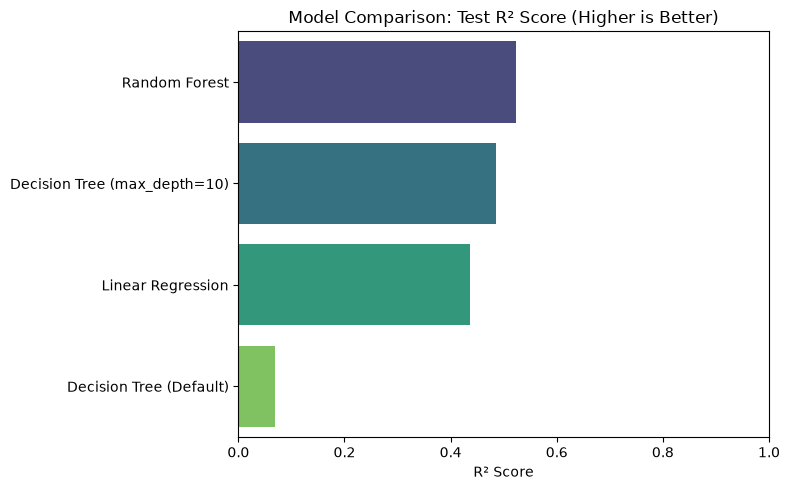

In [15]:
# Visualize the results as a bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Test R² Score', y='Model', data=results_df, palette='viridis', hue='Model', legend=False)

plt.title('Model Comparison: Test R² Score (Higher is Better)')
plt.xlabel('R² Score')
plt.ylabel('')
plt.xlim(0, 1.0) # Lock the X-axis between 0 and 1 (100% accuracy)
plt.tight_layout()
plt.show()

## 5 — Model Behavior (Strengths & Weaknesses)

Based on real estate data science best practices, here is a breakdown of how these models behave:

### 1. Linear Regression (Our Baseline)
* **How it works:** Draws a single straight line through the data. Assumes that adding 100 sq ft increases the price by the exact same dollar amount for a $200k house as it does for a $5M house.
* **Strengths:** 
  * Very fast to train.
  * Extremely easy to explain (you can look at the coefficients and say "each bathroom adds exactly $X").
* **Weaknesses:** 
  * Too simple (underfits). It struggles to learn complex non-linear relationships.

### 2. Decision Tree (Default vs Tuned)
* **How it works:** Asks a series of Yes/No questions (e.g., "Is LivingArea > 2000?", then "Is YearBuilt > 2010?") to slice the data into distinct buckets.
* **Default (Unconstrained):** By default, a Decision Tree grows infinitely deep until every training row has its own leaf. On a massive dataset of 380,000+ rows, this causes severe **Overfitting** (R² = 1.0 on train, but drops to ~0.06 on test) because it memorized training noise.
* **Tuned (`max_depth=10`):** Setting `max_depth=10` limits how deep the tree can grow. This prevents the tree from memorizing individual rows, curing the overfitting and jumping the test R² score up to ~0.48+!

### 3. Random Forest
* **How it works:** An "Ensemble" model. It builds 100+ different Decision Trees, each looking at a random subset of the data and features. When predicting a house's price, it asks all 100 trees for their guess and takes the average.
* **Strengths:**
  * Hugely powerful. It captures non-linear rules without overfitting because the "wisdom of the crowd" averages out individual tree errors.
  * Delivers the highest R² score of all models (52%+).
* **Weaknesses:**
  * Slower to train and acts as a "Black Box" (harder to explain individual predictions).